<a href="https://colab.research.google.com/github/lcbjrrr/algojust/blob/main/Pmpt02_selectionBias_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Selection bias

- **Selection bias**: Occurs when the data sample is not representative of the target population. This can happen due to non-random sampling, over- or underrepresentation of certain groups, or self-selection bias. For example, a study on the health effects of alcohol that only recruits participants from bars and nightclubs will not represent the general population's alcohol consumption habits

*The data used herein is for illustrative purposes only and does not reflect actual real-world data*

Download: [Census-USA.csv](https://raw.githubusercontent.com/lcbjrrr/algojust/refs/heads/main/Census%20-%20USA.csv)



> Read the 'Census - USA.csv' file and show the dataframe

In [6]:
import pandas as pd

df = pd.read_csv('/content/Census - USA.csv')
df.head()

,State,female,Race,Citizen,Income,Profession
0,Alabama,1,Black,False,44922.0,SelfEmployed
1,Alabama,1,White,True,51965.0,PublicWork
2,Alabama,1,Hispanic,False,63092.0,PrivateWork
3,Alabama,1,Black,True,34821.0,PrivateWork
4,Alabama,1,Asian,False,31390.0,SelfEmployed


#### Is it correct that the majority of Americans are either Hispanic or Asian?



> Create a aggregated table grouped by Race and count the number of people of each. Then show a bar plot comparing those

Aggregated table of people by Race:
 Race
White       22856
Hispanic    21625
Asian       17045
Black        5724
Native       3773
Pacific      2288
Name: count, dtype: int64


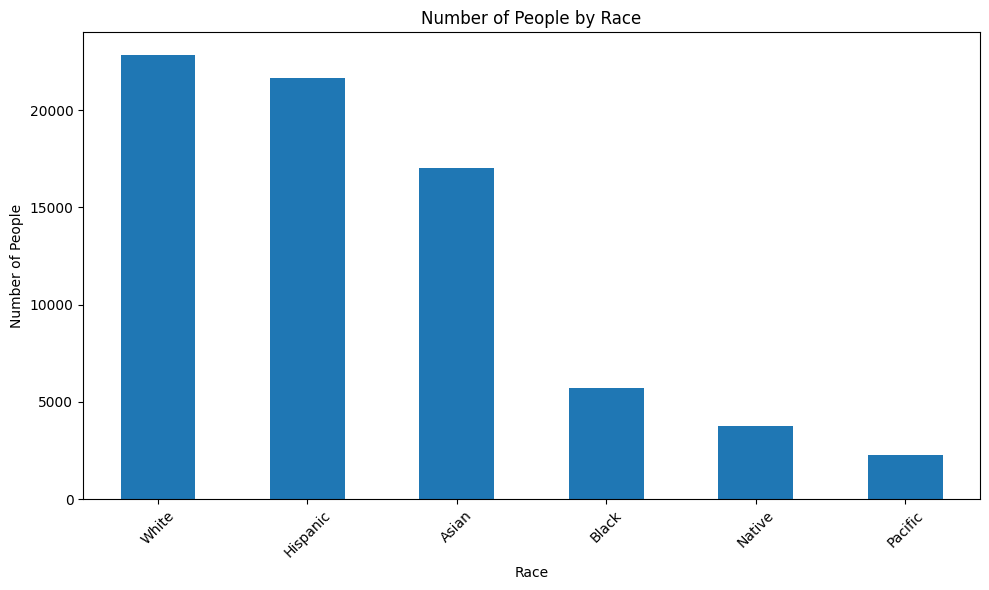

In [2]:
import matplotlib.pyplot as plt

race_counts = df['Race'].value_counts()
print("Aggregated table of people by Race:\n", race_counts)

plt.figure(figsize=(10, 6))
race_counts.plot(kind='bar')
plt.title('Number of People by Race')
plt.xlabel('Race')
plt.ylabel('Number of People')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*This graph does not accurately represent general US demographics. The dataset significantly overrepresents Hispanic and Asian populations while underrepresenting White and Black populations compared to national averages. This indicates selection bias within the sample, meaning it is not representative of the broader US population*

#### Is this data sample a realistic representation of the population that we are trying to analyze?





> Aggregate the data by Citzen status and count each person based on that. After that plot a pie chat showing hte propotion of those


Aggregated table of people by Citizen status:
 Citizen
False    38709
True     34602
Name: count, dtype: int64


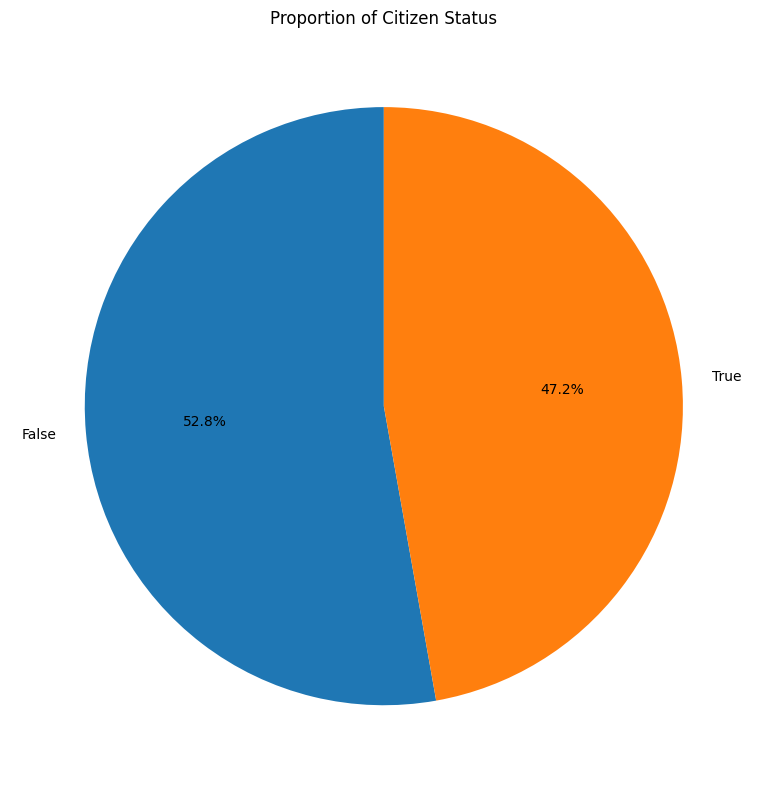

In [3]:
import matplotlib.pyplot as plt

citizen_counts = df['Citizen'].value_counts()
print("Aggregated table of people by Citizen status:\n", citizen_counts)

plt.figure(figsize=(8, 8))
citizen_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Citizen Status')
plt.ylabel('') # Hide the default 'Citizen' label on the y-axis for pie chart
plt.tight_layout()
plt.show()

*The pie chart indicates that the dataset contains a slightly higher proportion of non-citizens (approximately 52.8%) compared to citizens (approximately 47.2%*).



> Create a dataframe filtered only with citzens

In [5]:
df_citizens = df[df['Citizen'] == True]
df_citizens.head()

,State,female,Race,Citizen,Income,Profession
1,Alabama,1,White,True,51965.0,PublicWork
3,Alabama,1,Black,True,34821.0,PrivateWork
7,Alabama,1,Black,True,51206.0,PublicWork
10,Alabama,1,White,True,41970.0,PrivateWork
13,Alabama,1,Black,True,24464.0,PrivateWork


> Create a aggregated table grouped by Race and count the number of people of each. Then show a bar plot comparing those


Aggregated table of citizens by Race:
 Race
White       16283
Hispanic     7848
Asian        3989
Black        2629
Native       2097
Pacific      1756
Name: count, dtype: int64


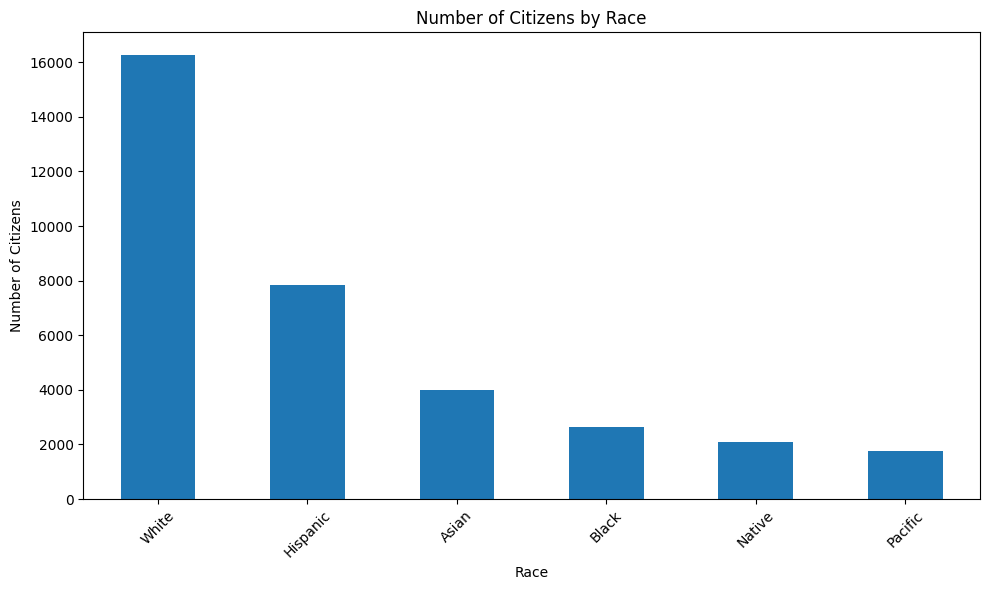

In [7]:
import matplotlib.pyplot as plt

citizens_race_counts = df_citizens['Race'].value_counts()
print("Aggregated table of citizens by Race:\n", citizens_race_counts)

plt.figure(figsize=(10, 6))
citizens_race_counts.plot(kind='bar')
plt.title('Number of Citizens by Race')
plt.xlabel('Race')
plt.ylabel('Number of Citizens')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*US citizen demographics filtered only by citzens: White citizens make up approximately 47.06% of the citizen population; Hispanic citizens are about 22.68% in this dataset; Asian citizens represent about 11; Black citizens account for about 7.60%.*




#### Back to the Citizen vs Non-citizen, the Aliens residents leans more on the welfare programs and usually don't work.



> Aggregate the original dataset grouping by Profession and Citzen. Plot a bar chart comparing those, having the Citzenship with different colors (hue)

Aggregated table grouped by Profession and Citizen:
      Profession  Citizen  Count
0    FamilyWork    False   1631
1    FamilyWork     True   1204
2   PrivateWork    False  16423
3   PrivateWork     True  16657
4    PublicWork    False   4170
5    PublicWork     True   3446
6  SelfEmployed    False  11755
7  SelfEmployed     True   8836
8  Unemployment    False   4730
9  Unemployment     True   4459


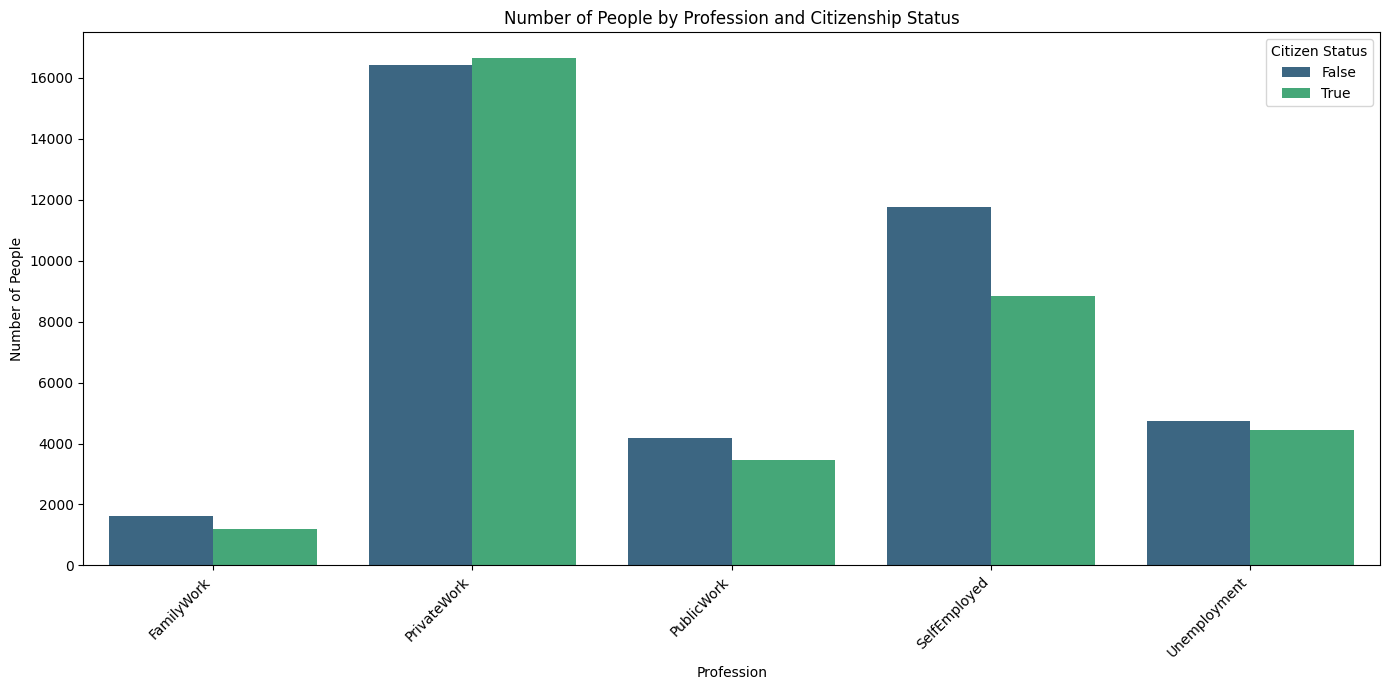

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate the original dataset grouping by Profession and Citizen
aggregated_df = df.groupby(['Profession', 'Citizen']).size().reset_index(name='Count')
print("Aggregated table grouped by Profession and Citizen:\n", aggregated_df)

# Plot a bar chart comparing those, having the Citizenship with different colors (hue)
plt.figure(figsize=(14, 7))
sns.barplot(data=aggregated_df, x='Profession', y='Count', hue='Citizen', palette='viridis')
plt.title('Number of People by Profession and Citizenship Status')
plt.xlabel('Profession')
plt.ylabel('Number of People')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.legend(title='Citizen Status')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

*The raw count of unemployed individuals is roughly similar between Citizens and Non-Citizens. For non-citizens, challenging the idea that they 'usually don't work'*.



####  Even when an alien resident works, they do it for lower salaries.



> Create a boxplot of the Income broken down by Citzenship

/tmp/ipykernel_1284/3866053242.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Citizen', y='Income', palette='coolwarm')


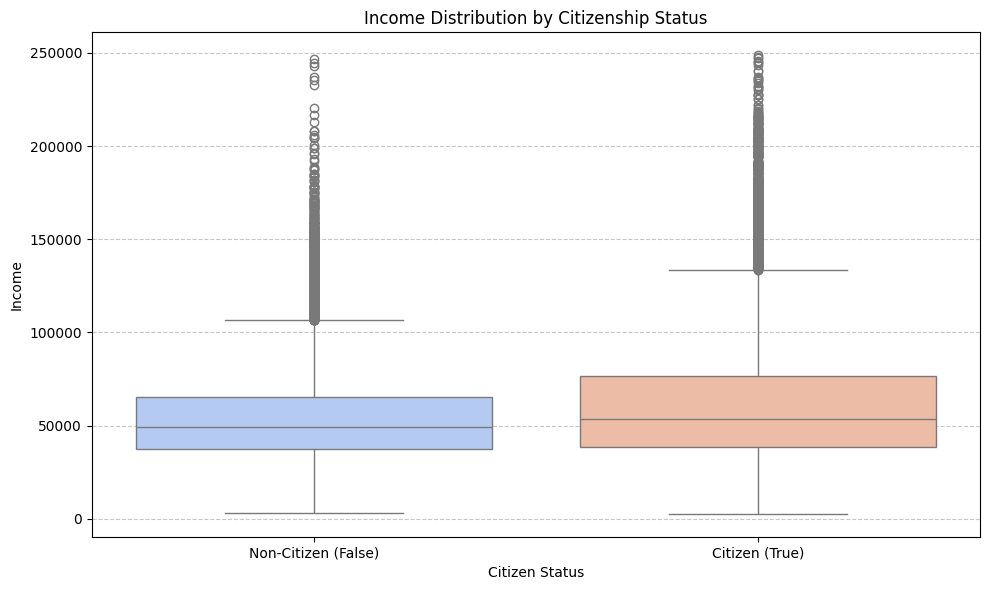

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot of Income broken down by Citizenship
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Citizen', y='Income', palette='coolwarm')
plt.title('Income Distribution by Citizenship Status')
plt.xlabel('Citizen Status')
plt.ylabel('Income')
plt.xticks(ticks=[0, 1], labels=['Non-Citizen (False)', 'Citizen (True)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Boxplot indicates that non-citizens generally have a lower median income compared to citizens. To verify this observation quantitatively, I will calculate and display the summary statistics for income grouped by citizenship status



> Create another boxplot of the Income broken down by Profession, and separete by color (hue) the Citzenship

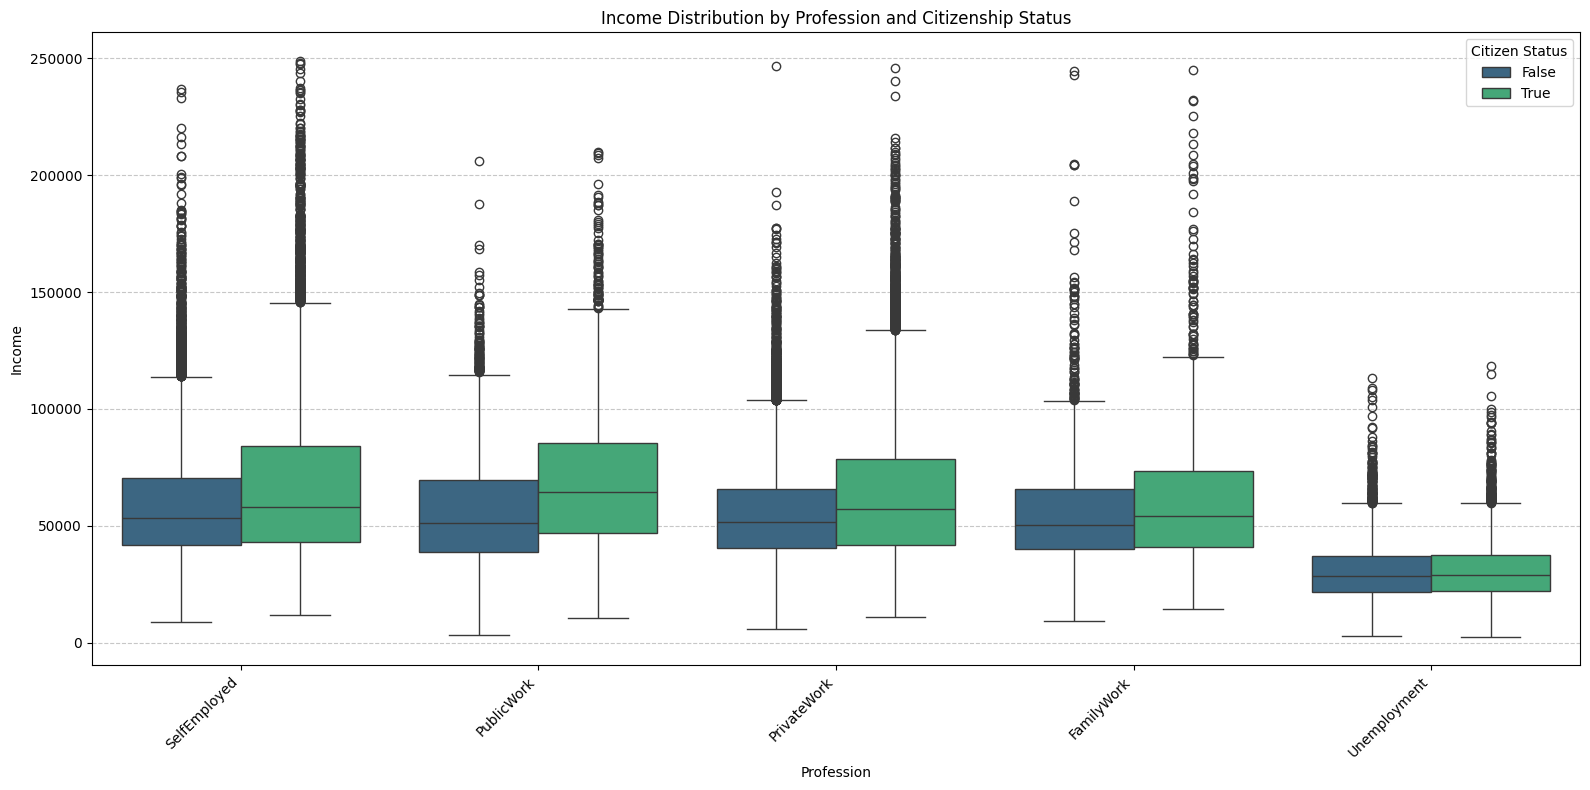

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot of Income broken down by Profession, separated by Citizenship (hue)
plt.figure(figsize=(16, 8))
sns.boxplot(data=df, x='Profession', y='Income', hue='Citizen', palette='viridis')
plt.title('Income Distribution by Profession and Citizenship Status')
plt.xlabel('Profession')
plt.ylabel('Income')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.legend(title='Citizen Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

*Across most professions, you'll observe a consistent trend where the median income for citizens is notably higher than that for non-citizens. This is evident by the median line within the citizen's box being positioned above the median line for non-citizens within the same professional category*.



#### Changing subject... Government/Public works earn more than other sectors, including the Private market.



> Create a boxplot of the Income broken down by Profession

/tmp/ipykernel_1284/2907359889.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Profession', y='Income', palette='coolwarm')


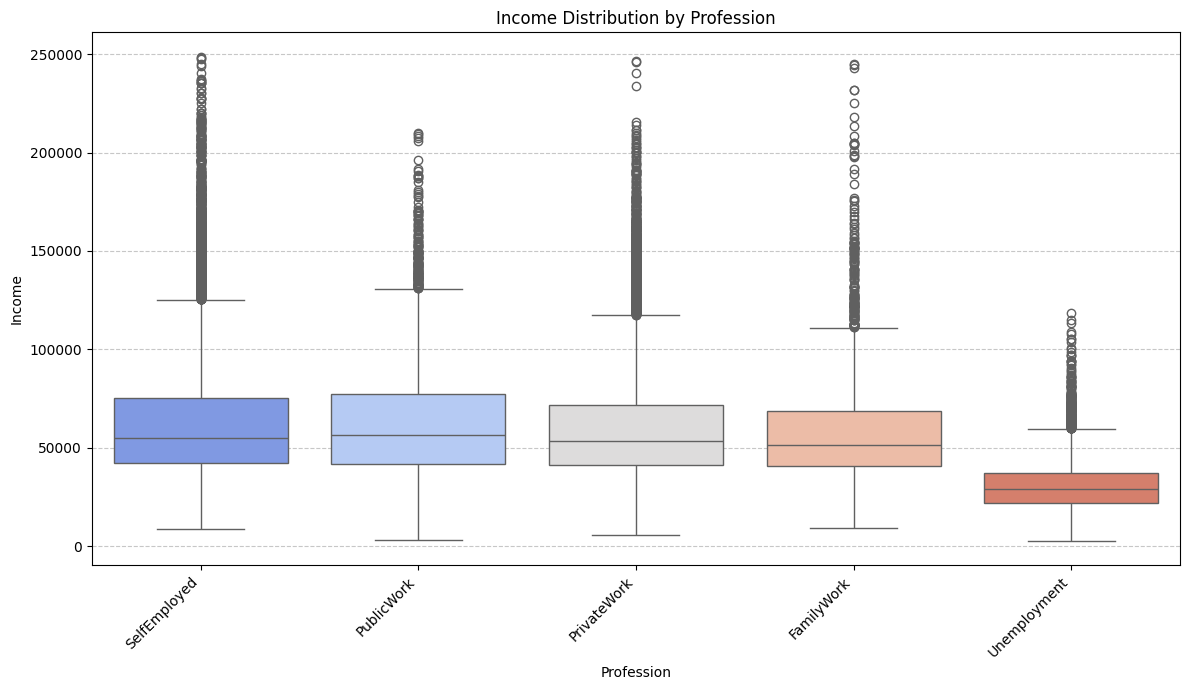

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot of Income broken down by Profession
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='Profession', y='Income', palette='coolwarm')
plt.title('Income Distribution by Profession')
plt.xlabel('Profession')
plt.ylabel('Income')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

*Based on the boxplot of income distribution by profession, we can visually examine the median income for each category, from it we don't see a median higher salary for Goverment work*.



#### Maybe this is true for particular places? How about Virginia/DC ...



> Create a dataset filtered only by Virgina (DC) state.

In [12]:
states_to_filter = ['Virginia', 'District of Columbia']
df_virginia_dc = df[df['State'].isin(states_to_filter)]

print("Dataset filtered for Virginia and District of Columbia (DC):")
df_virginia_dc.head()

Dataset filtered for Virginia and District of Columbia (DC):


,State,female,Race,Citizen,Income,Profession
3177,District of Columbia,1,White,True,175048.0,PublicWork
3178,District of Columbia,1,White,False,NaN,FamilyWork
3179,District of Columbia,1,White,False,153705.0,PrivateWork
3180,District of Columbia,1,White,False,125078.0,PublicWork
3181,District of Columbia,1,Native,False,107448.0,PublicWork


> Create a boxplot of the Income broken down, only for this VA dataset


/tmp/ipykernel_1284/2106671504.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_virginia_dc, x='Profession', y='Income', palette='viridis')


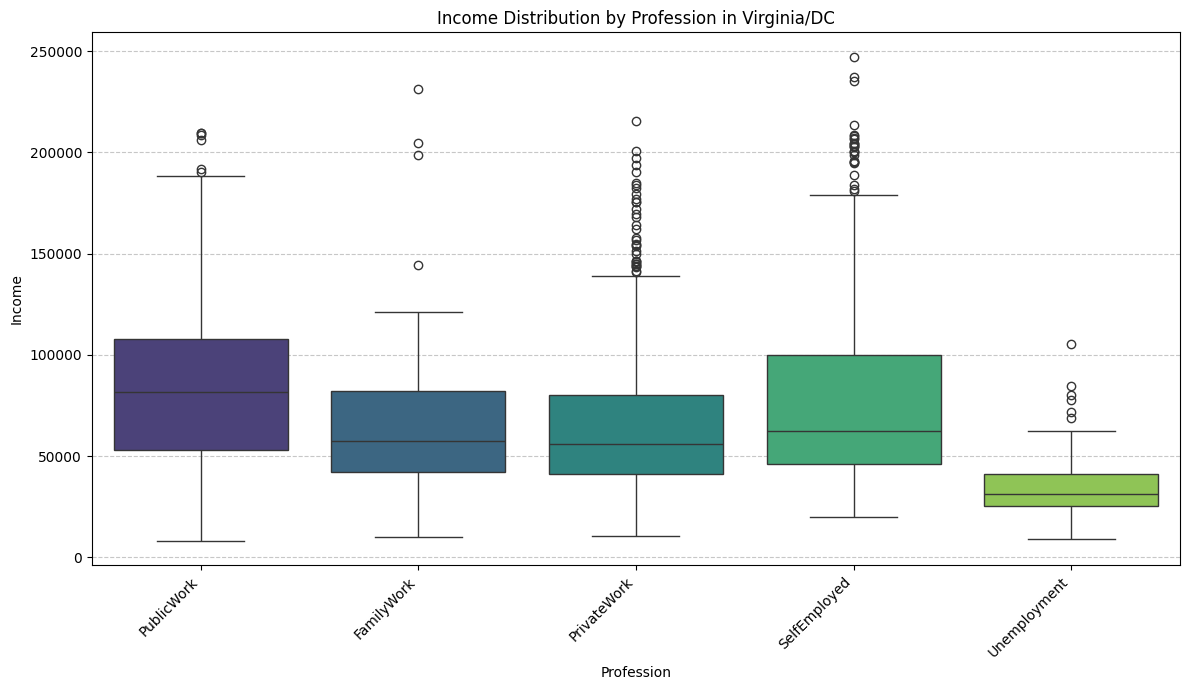

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot of Income broken down by Profession for the df_virginia_dc dataset
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_virginia_dc, x='Profession', y='Income', palette='viridis')
plt.title('Income Distribution by Profession in Virginia/DC')
plt.xlabel('Profession')
plt.ylabel('Income')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

*The central tendency of higher income for each profession within the Virginia dataset*



> From the VA dataset, filter only for the PublicWork, and calculate the quartiles, using the describe function

In [14]:
public_work_va_dc = df_virginia_dc[df_virginia_dc['Profession'] == 'PublicWork']

# Calculate quartiles and other descriptive statistics for 'Income'
income_quartiles_public_work = public_work_va_dc['Income'].describe()

print("Descriptive statistics for Income in PublicWork (Virginia/DC):")
print(income_quartiles_public_work)

Descriptive statistics for Income in PublicWork (Virginia/DC):
count       741.000000
mean      84949.547908
std       36995.981441
min        8043.000000
25%       53266.000000
50%       81691.000000
75%      108004.000000
max      209698.000000
Name: Income, dtype: float64


- *The graph indicates that 25% of Public Work professionals in Virginia earn below $52,062.75, 50% earn below \$52,062, 50% earn below \$80,625, and 75% earn below \$107,949*



#### One last topic, similarly to the simple bar plot comparing Profession (categorical) and Citzenship (binary). In case we had two categorical variables, how could we compare those?



> Count the percentage of people, cross referecing the Profession vs the Race, and show the bar chart comparing those

Percentage of people by Profession and Race (row-normalized):
Race          Asian  Black  Hispanic  Native  Pacific  White
Profession                                                  
FamilyWork    30.69   4.97     29.49    7.02     2.29  25.54
PrivateWork   24.64   5.16     27.68    4.14     3.02  35.36
PublicWork    17.23  11.42     26.29    6.92     4.49  33.65
SelfEmployed  29.68   3.20     27.63    5.59     2.94  30.96
Unemployment   6.54  25.54     42.87    5.74     3.00  16.31


<Figure size 1500x800 with 0 Axes>

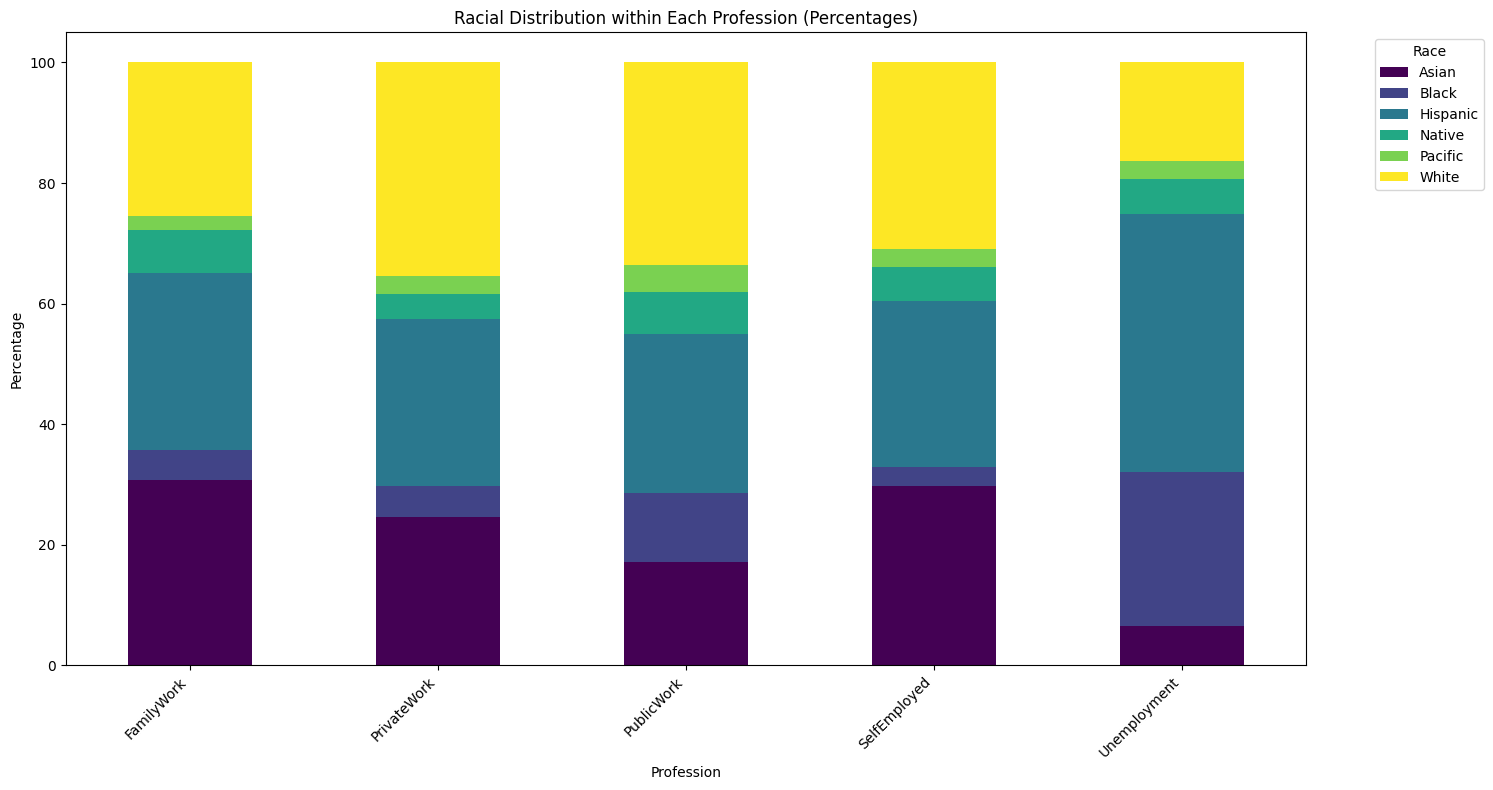

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a cross-tabulation of Profession and Race
crosstab_prof_race = pd.crosstab(df['Profession'], df['Race'])

# Calculate percentages for each profession (normalized by row)
# This shows, for each profession, the percentage distribution of races within it
percentage_prof_race = crosstab_prof_race.div(crosstab_prof_race.sum(axis=1), axis=0) * 100

print("Percentage of people by Profession and Race (row-normalized):")
print(percentage_prof_race.round(2))

# Plot a stacked bar chart
plt.figure(figsize=(15, 8))
percentage_prof_race.plot(kind='bar', stacked=True, colormap='viridis', figsize=(15, 8))
plt.title('Racial Distribution within Each Profession (Percentages)')
plt.xlabel('Profession')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Race', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

*The analysis reveals that the dataset exhibits a varied racial distribution across professions. While White individuals are highly represented in 'PrivateWork' and 'PublicWork', Hispanic and Asian populations show strong representation in 'FamilyWork' and 'SelfEmployed'. Notably, the 'Unemployment' category has a significant overrepresentation of Hispanic and Black individuals, highlighting potential disparities in employment dynamics within the dataset*.


## Activity: Selection Bias




**Problem**  

Your goal is to demonstrate how analyzing a biased subset of data can lead to different, potentially misleading, insights compared to analyzing the complete, representative dataset. Go to Kaggle and select a publicly available dataset and load your chosen dataset into your analytical environment. With that, choose one or two specific aspects or relationships e that you find interesting to analyze. Then:

- Select the first 10% of the records as your "biased sample": Formulate a preliminary conclusion or hypothesis based only on this first 10% of the data.

- Comprehensive Analysis (Full Dataset): Now, perform the exact same analysis (i.e., focusing on the same aspects or relationships) using the entire dataset.

**Comparison of Conclusions**

Carefully compare the conclusions, patterns, and insights you drew from the initial 10% biased sample with those derived from the full dataset. Do your preliminary conclusions from the biased sample still hold true, or are they contradicted by the full dataset analysis? Relate your observations back to the definition of selection bias provided: "Occurs when the data sample is not representative of the target population. This can happen due to non-random sampling, over- or under-representation of certain groups, or self-selection bias.
